In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df=pd.read_csv('../data/EV_cars.csv')
df.head(2)

,Battery,Car_name,Car_name_link,Efficiency,Fast_charge,Price.DE.,Range,Top_speed,acceleration..0.100.
0,75.0,Tesla Model Y Long Range Dual Motor,https://ev-database.org/car/1619/Tesla-Model-Y...,172,670.0,59017.0,435,217,5.0
1,57.5,Tesla Model 3,https://ev-database.org/car/1991/Tesla-Model-3,137,700.0,46220.0,420,201,6.1


In [58]:
df.drop('Car_name_link',axis=1,inplace=True)

In [59]:
df.columns=df.columns.str.lower()

In [60]:
df['car_name'].unique()

array(['Tesla Model Y Long Range Dual Motor', 'Tesla Model 3',
       'BYD ATTO 3', 'MG MG4 Electric 64 kWh',
       'Tesla Model 3 Long Range Dual Motor', 'Tesla Model Y',
       'BMW iX xDrive40', 'Volvo EX30 Single Motor ER', 'Citroen e-C3',
       'BYD SEAL 82.5 kWh AWD Excellence', 'BMW i4 eDrive40',
       'Renault Megane E-Tech EV60 220hp', 'BMW iX1 xDrive30',
       'Hyundai Kona Electric 64 kWh', 'Tesla Model Y Performance',
       'Kia Niro EV', 'Rolls-Royce Spectre', 'Tesla Model S Plaid',
       'BMW iX3', 'Hongqi E-HS9 99 kWh', 'Fiat 500e Hatchback 42 kWh',
       'BYD HAN', 'Tesla Model S Dual Motor', 'BYD DOLPHIN 60.4 kWh',
       'CUPRA Born 150 kW - 58 kWh', 'Dacia Spring Electric 45',
       'BMW i5 eDrive40 Sedan', 'BMW i4 M50', 'Opel Astra Electric',
       'MG ZS EV Long Range', 'Audi Q4 e-tron 40', 'BMW i7 xDrive60',
       'Toyota bZ4X FWD', 'Volvo EX30 Single Motor', 'Smart #1',
       'Kia EV6 Long Range 2WD', 'Volkswagen ID.7 Pro', 'BMW iX xDrive50',
       'A

In [61]:
df.head(2)

,battery,car_name,efficiency,fast_charge,price.de.,range,top_speed,acceleration..0.100.
0,75.0,Tesla Model Y Long Range Dual Motor,172,670.0,59017.0,435,217,5.0
1,57.5,Tesla Model 3,137,700.0,46220.0,420,201,6.1


In [62]:
df['car_name'].str.split().str[0]

0        Tesla
1        Tesla
2          BYD
3           MG
4        Tesla
        ...   
355    Citroen
356       Fiat
357       Opel
358       Opel
359       Fiat
Name: car_name, Length: 360, dtype: object

In [63]:
df['brand']=df['car_name'].str.split().str[0]


In [64]:
df['car_name'].unique()

array(['Tesla Model Y Long Range Dual Motor', 'Tesla Model 3',
       'BYD ATTO 3', 'MG MG4 Electric 64 kWh',
       'Tesla Model 3 Long Range Dual Motor', 'Tesla Model Y',
       'BMW iX xDrive40', 'Volvo EX30 Single Motor ER', 'Citroen e-C3',
       'BYD SEAL 82.5 kWh AWD Excellence', 'BMW i4 eDrive40',
       'Renault Megane E-Tech EV60 220hp', 'BMW iX1 xDrive30',
       'Hyundai Kona Electric 64 kWh', 'Tesla Model Y Performance',
       'Kia Niro EV', 'Rolls-Royce Spectre', 'Tesla Model S Plaid',
       'BMW iX3', 'Hongqi E-HS9 99 kWh', 'Fiat 500e Hatchback 42 kWh',
       'BYD HAN', 'Tesla Model S Dual Motor', 'BYD DOLPHIN 60.4 kWh',
       'CUPRA Born 150 kW - 58 kWh', 'Dacia Spring Electric 45',
       'BMW i5 eDrive40 Sedan', 'BMW i4 M50', 'Opel Astra Electric',
       'MG ZS EV Long Range', 'Audi Q4 e-tron 40', 'BMW i7 xDrive60',
       'Toyota bZ4X FWD', 'Volvo EX30 Single Motor', 'Smart #1',
       'Kia EV6 Long Range 2WD', 'Volkswagen ID.7 Pro', 'BMW iX xDrive50',
       'A

In [65]:
df['drive_type']=df['car_name'].str.extract(r'(AWD|RWD|FWD|2WD)')

In [66]:
df['drive_type'].unique()

array([nan, 'AWD', 'FWD', '2WD', 'RWD'], dtype=object)

In [67]:
df['drive_type'] = df['drive_type'].replace('2WD', 'FWD')
df['drive_type'] = df['drive_type'].fillna('unknown')

In [68]:
df['variant'] = df['car_name'].str.lower().str.extract(
    r'(long range|performance|plaid|gtx|gt|pro s|pro|rs|amg|brabus|m\d{2}|excellence|design|ultra|extreme|dream edition|grand touring|touring)'
)

In [69]:
df['variant']=df['variant'].fillna('standard')

In [70]:
df.drop('car_name',axis=1,inplace=True)

In [71]:
df.head(10)

,battery,efficiency,fast_charge,price.de.,range,top_speed,acceleration..0.100.,brand,drive_type,variant
0,75.0,172,670.0,59017.0,435,217,5.0,Tesla,unknown,long range
1,57.5,137,700.0,46220.0,420,201,6.1,Tesla,unknown,standard
2,60.5,183,370.0,44625.0,330,160,7.3,BYD,unknown,standard
3,61.7,171,630.0,39990.0,360,160,7.9,MG,unknown,standard
4,75.0,149,780.0,55220.0,505,201,4.4,Tesla,unknown,long range
5,57.5,164,580.0,47567.0,350,217,6.9,Tesla,unknown,standard
6,71.0,197,480.0,77300.0,360,200,6.1,BMW,unknown,standard
7,64.0,173,550.0,41790.0,370,180,5.3,Volvo,unknown,standard
8,44.0,176,320.0,23300.0,250,135,11.0,Citroen,unknown,standard
9,82.5,170,530.0,53668.0,485,180,3.8,BYD,AWD,excellence


In [72]:
df.isnull().sum()

battery                  0
efficiency               0
fast_charge              2
price.de.               51
range                    0
top_speed                0
acceleration..0.100.     0
brand                    0
drive_type               0
variant                  0
dtype: int64

In [73]:
df['fast_charge']=df['fast_charge'].fillna(df['fast_charge'].median())

In [74]:
df.dropna(inplace=True)

In [75]:
df.isnull().sum()

battery                 0
efficiency              0
fast_charge             0
price.de.               0
range                   0
top_speed               0
acceleration..0.100.    0
brand                   0
drive_type              0
variant                 0
dtype: int64

In [76]:
# average price of cars 

print("Average Price of Cars:",df['price.de.'].mean())

Average Price of Cars: 67264.284789644


brand
Mercedes      37
Porsche       18
Opel          15
Peugeot       15
Citroen       15
BMW           15
Audi          14
Volvo         11
Volkswagen    10
NIO           10
Fiat          10
Hyundai       10
MG            10
Tesla         10
Kia            9
BYD            8
Nissan         7
Renault        7
Skoda          7
Polestar       6
Toyota         6
Smart          6
Zeekr          5
Lucid          5
Ford           4
Genesis        4
Fisker         4
CUPRA          3
VinFast        3
ORA            3
Dacia          2
Mini           2
Honda          2
Lotus          2
Aiways         2
Abarth         2
Subaru         1
Jeep           1
Jaguar         1
Mazda          1
Maxus          1
Lexus          1
DS             1
SsangYong      1
e.Go           1
Elaris         1
Name: count, dtype: int64



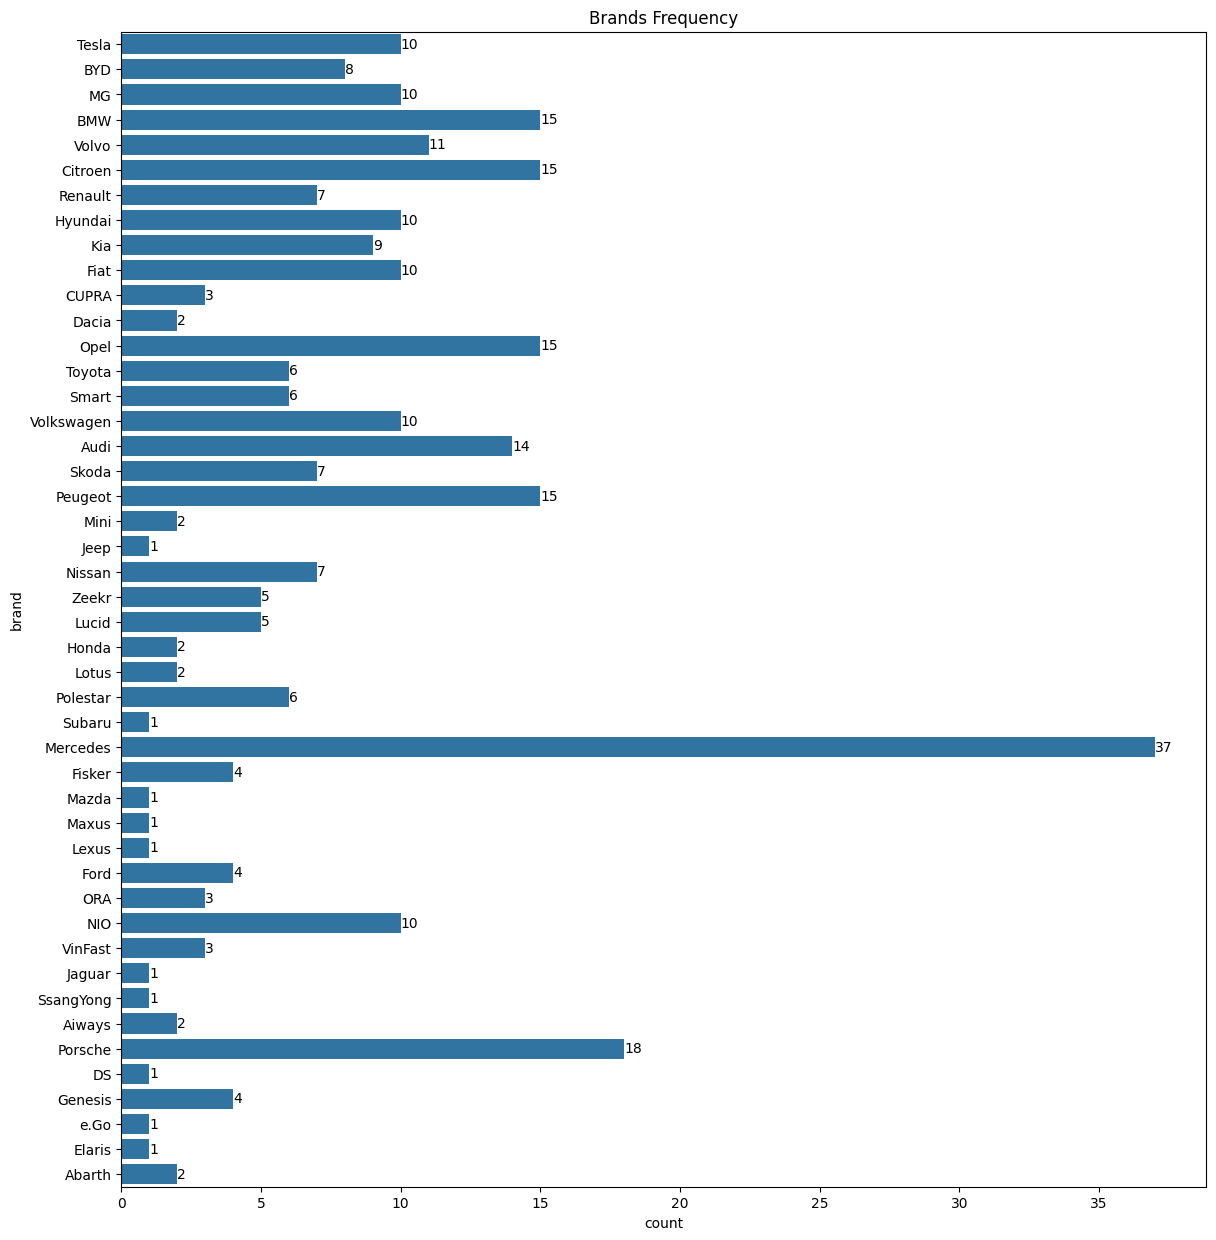

In [77]:
print(df['brand'].value_counts())
print()
plt.figure(figsize=(14,15))
ax=sns.countplot(df['brand'])
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Brands Frequency")
plt.show()

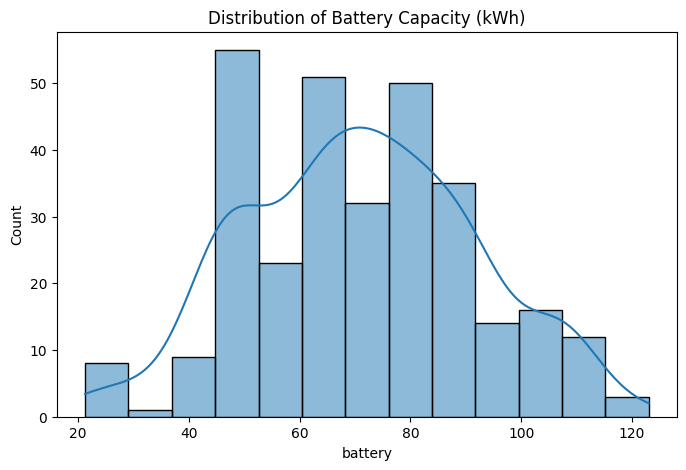

In [78]:

plt.figure(figsize=(8,5))

sns.histplot(df['battery'],kde=True)
plt.title("Distribution of Battery Capacity (kWh)")
plt.show()

In [79]:
# average range of cars 

print("Average Range of Cars:",df['range'].mean())

Average Range of Cars: 369.126213592233


Fastest car

In [80]:
df['acceleration..0.100.'].min()

np.float64(2.1)

In [81]:
df[df['acceleration..0.100.']==df['acceleration..0.100.'].min()]

,battery,efficiency,fast_charge,price.de.,range,top_speed,acceleration..0.100.,brand,drive_type,variant
17,95.0,170,780.0,110970.0,560,282,2.1,Tesla,unknown,plaid


Slowest Car

In [82]:
df['acceleration..0.100.'].max()

np.float64(19.1)

In [83]:
df[df['acceleration..0.100.']==df['acceleration..0.100.'].max()]

,battery,efficiency,fast_charge,price.de.,range,top_speed,acceleration..0.100.,brand,drive_type,variant
25,25.0,152,180.0,22550.0,165,125,19.1,Dacia,unknown,standard


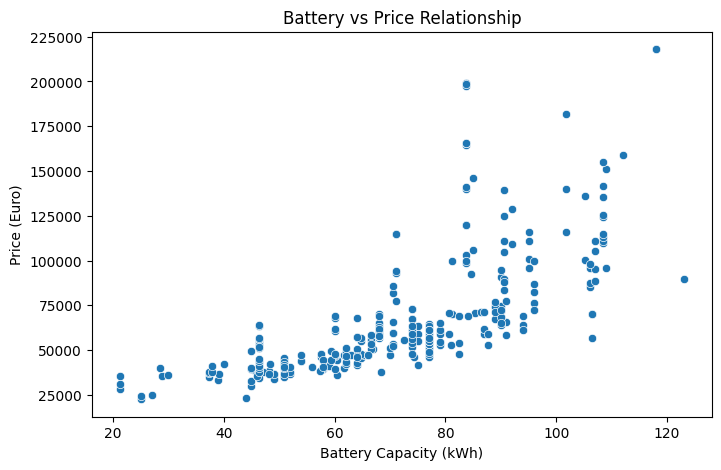

In [84]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['battery'], y=df['price.de.'])

plt.title("Battery vs Price Relationship")
plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Price (Euro)")

plt.show()

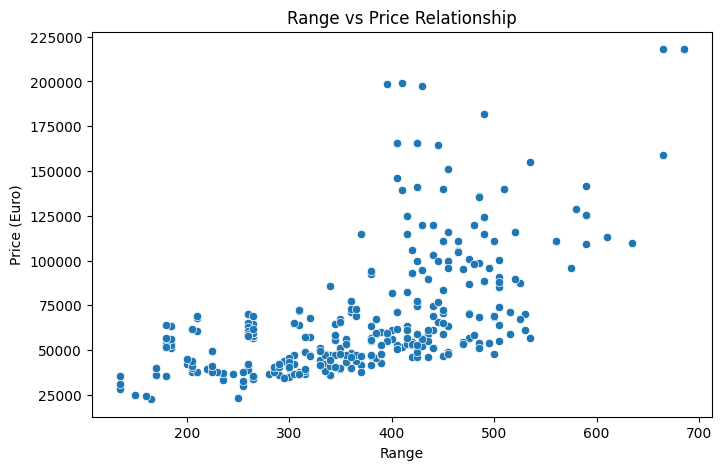

In [85]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['range'], y=df['price.de.'])

plt.title("Range vs Price Relationship")
plt.xlabel("Range")
plt.ylabel("Price (Euro)")

plt.show()

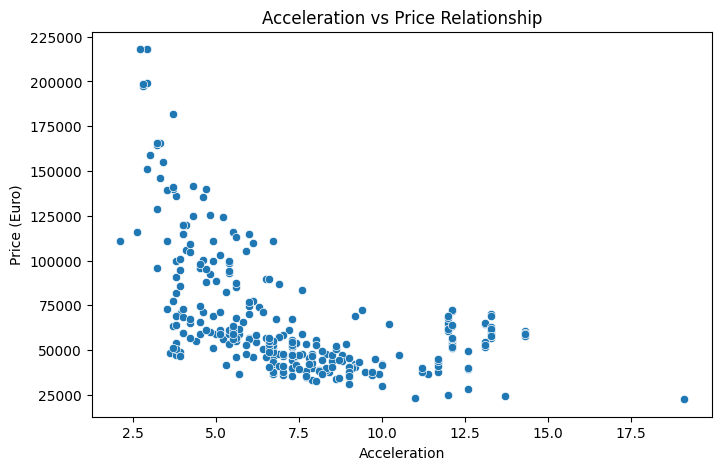

In [86]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['acceleration..0.100.'], y=df['price.de.'])

plt.title("Acceleration vs Price Relationship")
plt.xlabel("Acceleration")
plt.ylabel("Price (Euro)")

plt.show()

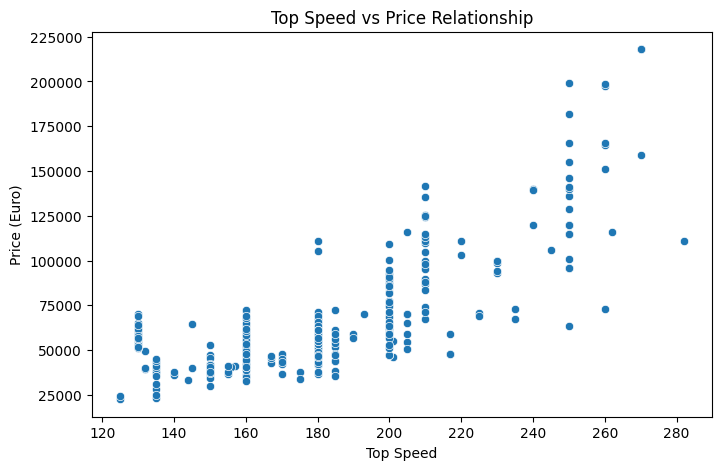

In [87]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['top_speed'], y=df['price.de.'])

plt.title("Top Speed vs Price Relationship")
plt.xlabel("Top Speed")
plt.ylabel("Price (Euro)")

plt.show()

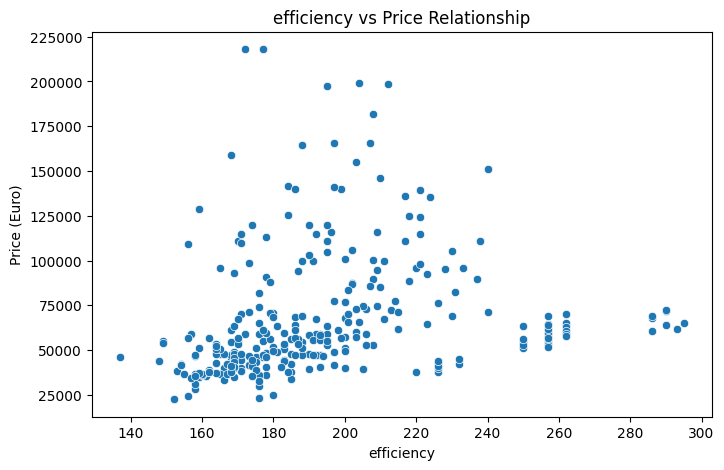

In [88]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['efficiency'], y=df['price.de.'])

plt.title("efficiency vs Price Relationship")
plt.xlabel("efficiency")
plt.ylabel("Price (Euro)")

plt.show()

         brand      price.de.
21       Lucid  166600.000000
33     Porsche  136131.111111
20       Lotus  123490.000000
16      Jaguar   92400.000000
3          BMW   88920.000000
25    Mercedes   87373.621622
2         Audi   79260.714286
27         NIO   74960.000000
39       Tesla   74313.800000
23       Maxus   68990.000000
32    Polestar   68850.000000
13     Genesis   68200.000000
19       Lexus   68000.000000
41     VinFast   67223.333333
12        Ford   64375.000000
18         Kia   61327.777778
43       Volvo   60624.545455
11      Fisker   59615.000000
44       Zeekr   58070.000000
38      Subaru   57490.000000
35       Skoda   53307.142857
9       Elaris   53090.000000
40      Toyota   52124.166667
30        Opel   51387.266667
28      Nissan   50635.714286
42  Volkswagen   50353.600000
31     Peugeot   49307.666667
4          BYD   48349.500000
15     Hyundai   47848.000000
6      Citroen   47391.333333
10        Fiat   45090.000000
36       Smart   44990.000000
29        

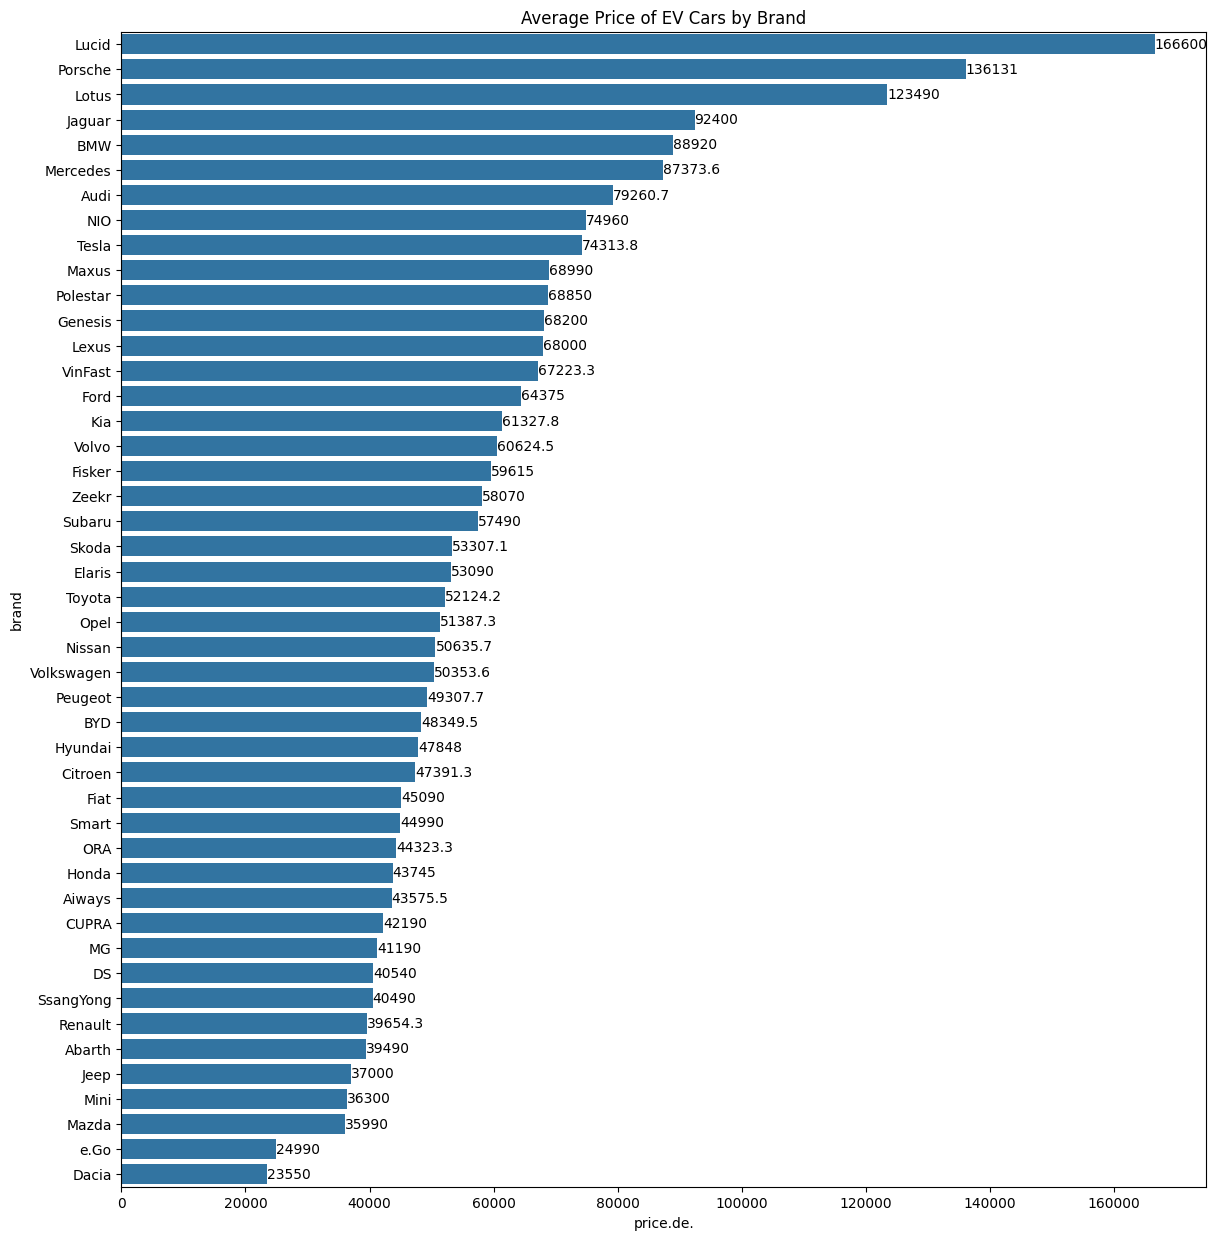

In [89]:
# Which brand has the highest average price?

gb1=df.groupby('brand')['price.de.'].mean().reset_index().sort_values(by='price.de.',ascending=False)

print(gb1)
print()

plt.figure(figsize=(14,15))
ax=sns.barplot(data=gb1,y='brand',x='price.de.')
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Average Price of EV Cars by Brand")
plt.show()

       brand  range
21     Lucid    685
25  Mercedes    635
39     Tesla    575
11    Fisker    535
44     Zeekr    530
2       Audi    525
3        BMW    520
41   VinFast    520
27       NIO    505
4        BYD    500



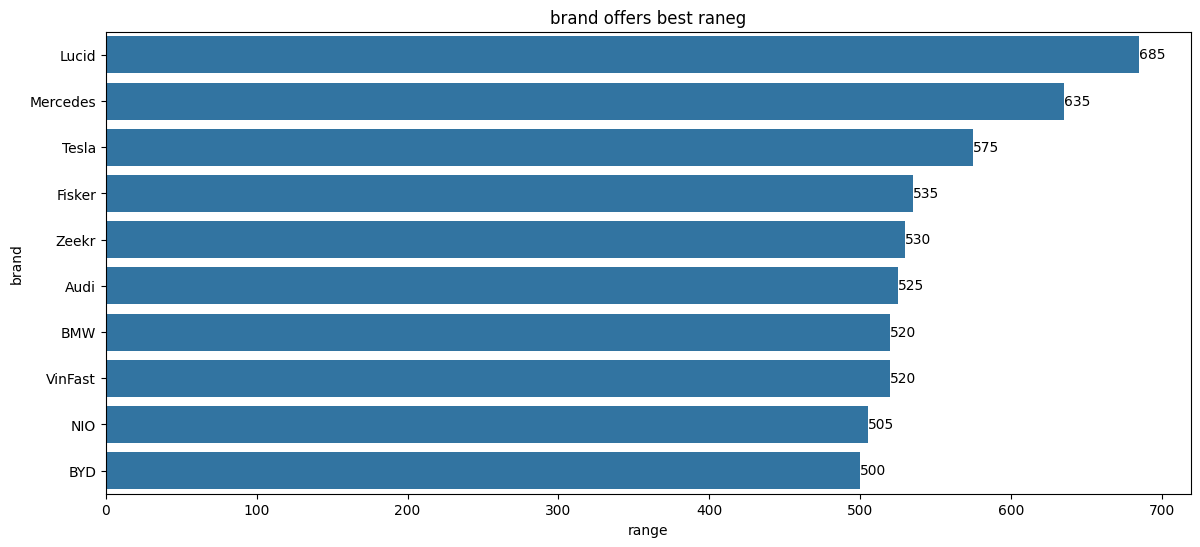

In [90]:
# Which brand offers the best range?

gb2=df.groupby('brand')['range'].max().reset_index().sort_values(by='range',ascending=False).head(10)

print(gb2)
print()

plt.figure(figsize=(14,6))
ax=sns.barplot(data=gb2,y='brand',x='range')
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("brand offers best raneg")
plt.show()

      brand  acceleration..0.100.
8     Dacia             16.400000
45     e.Go             12.000000
31  Peugeot             11.813333
6   Citroen             11.693333
30     Opel             11.300000
34  Renault             10.571429
40   Toyota             10.500000
10     Fiat             10.480000
24    Mazda              9.700000
23    Maxus              9.200000



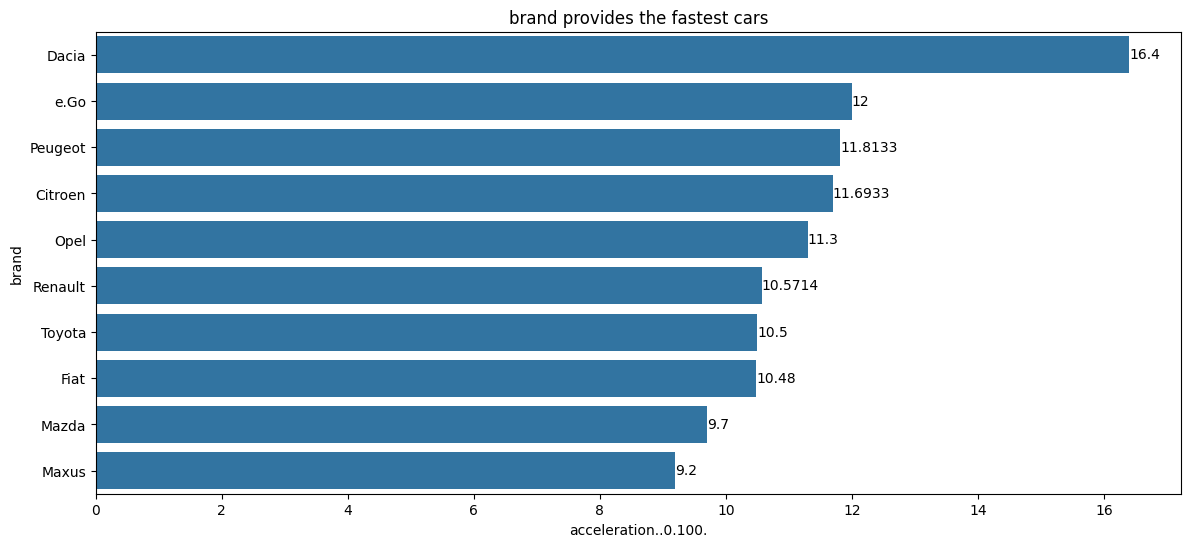

In [91]:
# Which brand provides the fastest cars?

gb3=df.groupby('brand')['acceleration..0.100.'].mean().reset_index().sort_values(by='acceleration..0.100.',ascending=False).head(10)

print(gb3)
print()

plt.figure(figsize=(14,6))
ax=sns.barplot(data=gb3,y='brand',x='acceleration..0.100.')
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("brand provides the fastest cars")
plt.show()

In [92]:
df['brand'].unique()

array(['Tesla', 'BYD', 'MG', 'BMW', 'Volvo', 'Citroen', 'Renault',
       'Hyundai', 'Kia', 'Fiat', 'CUPRA', 'Dacia', 'Opel', 'Toyota',
       'Smart', 'Volkswagen', 'Audi', 'Skoda', 'Peugeot', 'Mini', 'Jeep',
       'Nissan', 'Zeekr', 'Lucid', 'Honda', 'Lotus', 'Polestar', 'Subaru',
       'Mercedes', 'Fisker', 'Mazda', 'Maxus', 'Lexus', 'Ford', 'ORA',
       'NIO', 'VinFast', 'Jaguar', 'SsangYong', 'Aiways', 'Porsche', 'DS',
       'Genesis', 'e.Go', 'Elaris', 'Abarth'], dtype=object)

In [93]:
premium = ['Tesla', 'BMW', 'Audi', 'Mercedes', 'Porsche']

print('tesla' in premium)

False


In [94]:
def pre_notpre(brand):
    if brand in(premium):
        return 'premium'
    else:
        return 'not premium'

In [95]:
df['status']=df['brand'].apply(pre_notpre)

        status     price.de.
1      premium  94359.276596
0  not premium  55418.102326



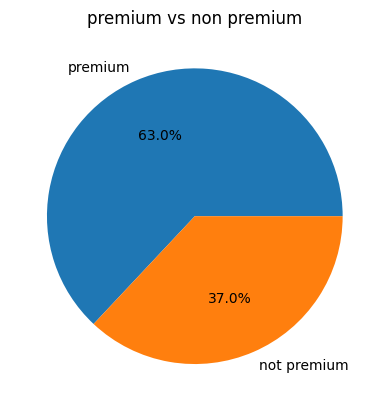

In [96]:
gb=df.groupby('status')['price.de.'].mean().reset_index().sort_values(by='price.de.',ascending=False)

print(gb)
print()

plt.pie(gb['price.de.'],labels=gb['status'],autopct='%1.1f%%')
plt.title("premium vs non premium")
plt.show()

  drive_type     price.de.
3    unknown  68004.162544
0        AWD  66308.307692
2        RWD  56884.666667
1        FWD  48024.285714



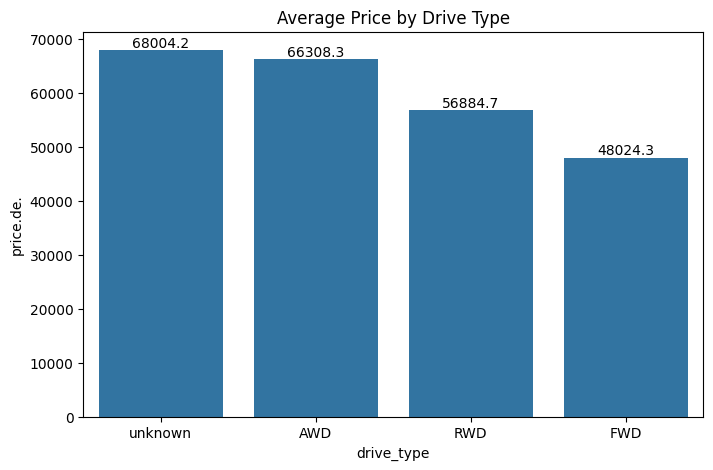

In [97]:
# Which drive type (AWD, FWD, RWD) is most expensive?

gb=df.groupby('drive_type')['price.de.'].mean().reset_index().sort_values(by='price.de.',ascending=False)

print(gb)
print()

plt.figure(figsize=(8,5))
ax=sns.barplot(data=gb,x='drive_type',y='price.de.')
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Average Price by Drive Type")
plt.show()

  drive_type  acceleration..0.100.
0        AWD              5.053846
2        RWD              7.066667
3    unknown              7.402473
1        FWD              7.900000



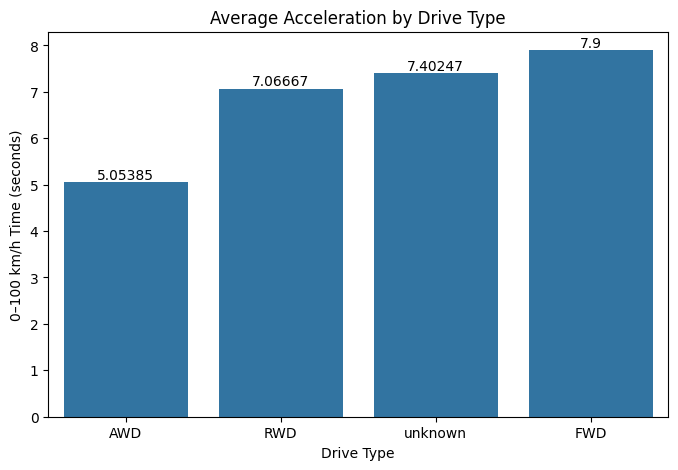

In [98]:
gb=df.groupby('drive_type')['acceleration..0.100.'].mean().reset_index().sort_values(by='acceleration..0.100.')

print(gb)
print()

plt.figure(figsize=(8,5))
ax = sns.barplot(data=gb, x='drive_type', y='acceleration..0.100.')

for bar in ax.containers:
    ax.bar_label(bar)

plt.title("Average Acceleration by Drive Type")
plt.xlabel("Drive Type")
plt.ylabel("0–100 km/h Time (seconds)")

plt.show()

          variant      price.de.
3   dream edition  218000.000000
12            m70  181800.000000
6   grand touring  159000.000000
0             amg  126965.800000
17             rs  120336.590909
11            m60  117800.000000
14          plaid  113470.000000
7              gt   89043.333333
19        touring   85666.666667
10            m50   70800.000000
13    performance   67553.400000
18       standard   58877.054299
9      long range   58244.235294
20          ultra   57000.000000
8             gtx   54855.000000
4      excellence   53668.000000
15            pro   50113.727273
1          brabus   49990.000000
16          pro s   47595.000000
2          design   47578.000000
5         extreme   47250.000000



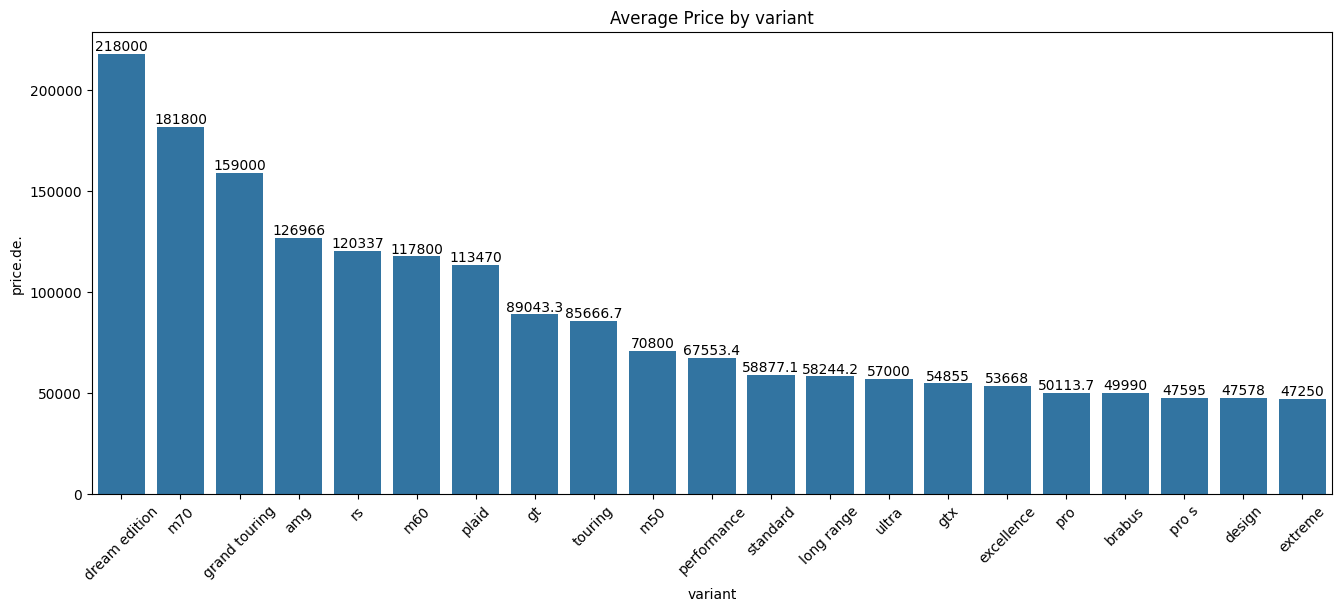

In [99]:
# Which variant is most expensive?

gb=df.groupby('variant')['price.de.'].mean().reset_index().sort_values(by='price.de.',ascending=False)

print(gb)
print()

plt.figure(figsize=(16,6))
ax=sns.barplot(data=gb,x='variant',y='price.de.')
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Average Price by variant")
plt.xticks(rotation=45)
plt.show()

In [100]:
df['is_long_range'] = df['variant'].str.contains('Long Range', case=False, na=False)

is_long_range
False    365.325342
True     434.411765
Name: range, dtype: float64



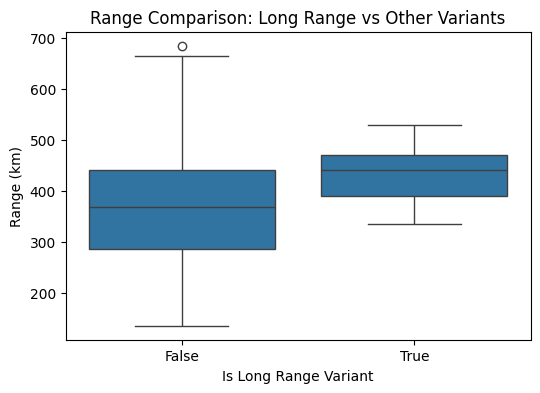

In [101]:
print(df.groupby('is_long_range')['range'].mean())
print()

plt.figure(figsize=(6,4))
sns.boxplot(x='is_long_range', y='range', data=df)
plt.title("Range Comparison: Long Range vs Other Variants")
plt.xlabel("Is Long Range Variant")
plt.ylabel("Range (km)")
plt.show()

In [102]:
df.drop(['status','is_long_range'],axis=1,inplace=True)

In [103]:
df.columns=df.columns.str.replace('.','_')

In [104]:
cat_cols=[i for i in df.columns if df[i].dtypes=='O']
num_cols=[i for i in df.columns if df[i].dtypes!='O']

cat_cols,num_cols

(['brand', 'drive_type', 'variant'],
 ['battery',
  'efficiency',
  'fast_charge',
  'price_de_',
  'range',
  'top_speed',
  'acceleration__0_100_'])

In [105]:
for i in cat_cols:
    print(df[i].unique())
    print("-"*30)
    print()

['Tesla' 'BYD' 'MG' 'BMW' 'Volvo' 'Citroen' 'Renault' 'Hyundai' 'Kia'
 'Fiat' 'CUPRA' 'Dacia' 'Opel' 'Toyota' 'Smart' 'Volkswagen' 'Audi'
 'Skoda' 'Peugeot' 'Mini' 'Jeep' 'Nissan' 'Zeekr' 'Lucid' 'Honda' 'Lotus'
 'Polestar' 'Subaru' 'Mercedes' 'Fisker' 'Mazda' 'Maxus' 'Lexus' 'Ford'
 'ORA' 'NIO' 'VinFast' 'Jaguar' 'SsangYong' 'Aiways' 'Porsche' 'DS'
 'Genesis' 'e.Go' 'Elaris' 'Abarth']
------------------------------

['unknown' 'AWD' 'FWD' 'RWD']
------------------------------

['long range' 'standard' 'excellence' 'performance' 'plaid' 'm50' 'pro'
 'design' 'gt' 'dream edition' 'brabus' 'm60' 'ultra' 'extreme' 'pro s'
 'grand touring' 'rs' 'touring' 'gtx' 'm70' 'amg']
------------------------------



In [106]:
df.groupby('brand')['price_de_'].mean()

brand
Abarth         39490.000000
Aiways         43575.500000
Audi           79260.714286
BMW            88920.000000
BYD            48349.500000
CUPRA          42190.000000
Citroen        47391.333333
DS             40540.000000
Dacia          23550.000000
Elaris         53090.000000
Fiat           45090.000000
Fisker         59615.000000
Ford           64375.000000
Genesis        68200.000000
Honda          43745.000000
Hyundai        47848.000000
Jaguar         92400.000000
Jeep           37000.000000
Kia            61327.777778
Lexus          68000.000000
Lotus         123490.000000
Lucid         166600.000000
MG             41190.000000
Maxus          68990.000000
Mazda          35990.000000
Mercedes       87373.621622
Mini           36300.000000
NIO            74960.000000
Nissan         50635.714286
ORA            44323.333333
Opel           51387.266667
Peugeot        49307.666667
Polestar       68850.000000
Porsche       136131.111111
Renault        39654.285714
Skoda         

In [107]:
df.to_csv('../data/ev_cars_cleaned.csv')

In [108]:
from sklearn.model_selection import train_test_split

train_df,test_df=train_test_split(df,test_size=0.20,random_state=42)

In [109]:
brand_encoded=train_df.groupby('brand')['price_de_'].mean()

train_df['brand']=train_df['brand'].map(brand_encoded)

test_df['brand']=test_df['brand'].map(brand_encoded)

In [110]:
train_df['variant'].unique()

array(['standard', 'extreme', 'amg', 'long range', 'pro', 'rs',
       'performance', 'design', 'plaid', 'touring', 'dream edition', 'gt',
       'grand touring', 'm70', 'm60', 'pro s', 'brabus', 'ultra'],
      dtype=object)

In [111]:
variant_encoded=train_df.groupby('variant')['price_de_'].mean()

train_df['variant']=train_df['variant'].map(variant_encoded)

test_df['variant']=test_df['variant'].map(variant_encoded)

In [112]:
global_mean = train_df['price_de_'].mean()
test_df['variant'] = test_df['variant'].fillna(global_mean)

In [113]:
global_mean = train_df['price_de_'].mean()
test_df['brand'] = test_df['brand'].fillna(global_mean)

In [114]:
cat_cols=[i for i in train_df.columns if train_df[i].dtypes=='O']
num_cols=[i for i in train_df.columns if train_df[i].dtypes!='O']

cat_cols,num_cols

(['drive_type'],
 ['battery',
  'efficiency',
  'fast_charge',
  'price_de_',
  'range',
  'top_speed',
  'acceleration__0_100_',
  'brand',
  'variant'])

In [115]:
type(num_cols)

list

In [116]:
num_cols.remove('price_de_')

In [117]:
num_cols

['battery',
 'efficiency',
 'fast_charge',
 'range',
 'top_speed',
 'acceleration__0_100_',
 'brand',
 'variant']

In [118]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

scaler=StandardScaler()
ohe=OneHotEncoder(drop='first')

preprocessor=ColumnTransformer(
    [
        ("StandardScaler",scaler,num_cols),
        ("OneHotEncoder",ohe,cat_cols)
    ]
)

In [119]:
preprocessor

ColumnTransformer(transformers=[('StandardScaler', StandardScaler(),
                                 ['battery', 'efficiency', 'fast_charge',
                                  'range', 'top_speed', 'acceleration__0_100_',
                                  'brand', 'variant']),
                                ('OneHotEncoder', OneHotEncoder(drop='first'),
                                 ['drive_type'])])

In [120]:
X_train=train_df.drop('price_de_',axis=1)
y_train=train_df['price_de_']

X_test=test_df.drop('price_de_',axis=1)
y_test=test_df['price_de_']

In [121]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((247, 9), (247,), (62, 9), (62,))

In [122]:
X_test.isnull().sum()

battery                 0
efficiency              0
fast_charge             0
range                   0
top_speed               0
acceleration__0_100_    0
brand                   0
drive_type              0
variant                 0
dtype: int64

In [123]:
X_test[X_test['brand'].isnull()]

,battery,efficiency,fast_charge,range,top_speed,acceleration__0_100_,brand,drive_type,variant


In [124]:
X_train_scaled=preprocessor.fit_transform(X_train)

X_test_scaled=preprocessor.transform(X_test)

In [125]:
X_train_scaled

array([[ 0.85921433,  0.39831955,  0.46615652, ...,  0.        ,
         0.        ,  1.        ],
       [-2.24961152, -1.22105971, -1.56330117, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.93693498, -0.02944101,  0.59040903, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.06371834, -0.12110399, -0.61069858, ...,  0.        ,
         0.        ,  1.        ],
       [-0.54947238,  2.75100262, -0.98345612, ...,  0.        ,
         0.        ,  1.        ],
       [-0.35517077, -0.39609292, -0.11368853, ...,  0.        ,
         0.        ,  0.        ]])

In [126]:
y_test

337     51940.0
9       53668.0
62      46335.0
67     218000.0
27      70800.0
         ...   
231    197740.0
228     35490.0
246     76650.0
262    124545.0
180     42000.0
Name: price_de_, Length: 62, dtype: float64

In [127]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVC, SVR

In [128]:
models = {

    # Regression
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "RandomForestRegressor": RandomForestRegressor(),
    "GradientBoostingRegressor": GradientBoostingRegressor(),
    "SVR": SVR(),
    "KNeighborsRegressor": KNeighborsRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor()
}

In [129]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [130]:
X_test.isnull().sum()

battery                 0
efficiency              0
fast_charge             0
range                   0
top_speed               0
acceleration__0_100_    0
brand                   0
drive_type              0
variant                 0
dtype: int64

In [131]:
best_r2={}
for name,model in models.items():

    print(f"{name} training...")

    model.fit(X_train_scaled,y_train)

    y_train_pred=model.predict(X_train_scaled)

    y_test_pred=model.predict(X_test_scaled)

    print("training performance")
    print("MAE:",mean_absolute_error(y_train,y_train_pred))
    print("MSE:",mean_squared_error(y_train,y_train_pred))
    print("RMSE:",np.sqrt(mean_squared_error(y_train,y_train_pred)))
    print("R2 score:",r2_score(y_train,y_train_pred))
    print()

    print("test data performance")
    print("MAE:",mean_absolute_error(y_test,y_test_pred))
    print("MSE:",mean_squared_error(y_test,y_test_pred))
    print("RMSE:",np.sqrt(mean_squared_error(y_test,y_test_pred)))
    print("R2 score:",r2_score(y_test,y_test_pred))

    best_r2[name]=r2_score(y_test,y_test_pred)
    print("-"*20)
    print()

LinearRegression training...
training performance
MAE: 9102.094093688058
MSE: 162858086.3953049
RMSE: 12761.586358885987
R2 score: 0.8535774087253989

test data performance
MAE: 11465.05053021702
MSE: 268816131.40385956
RMSE: 16395.61317559851
R2 score: 0.818691697493388
--------------------

Ridge training...
training performance
MAE: 9168.145076612194
MSE: 163383985.40832672
RMSE: 12782.174517988977
R2 score: 0.8531045829791322

test data performance
MAE: 11441.910411869967
MSE: 268224595.74611965
RMSE: 16377.563791544811
R2 score: 0.8190906702983936
--------------------

Lasso training...
training performance
MAE: 9103.176441412284
MSE: 162858365.83981594
RMSE: 12761.597307540147
R2 score: 0.8535771574821825

test data performance
MAE: 11463.18624781222
MSE: 268761628.3709845
RMSE: 16393.95096890876
R2 score: 0.8187284581309302
--------------------

RandomForestRegressor training...
training performance
MAE: 2435.5438273393274
MSE: 15623117.548059903
RMSE: 3952.608954609588
R2 score

In [132]:
best_r2

{'LinearRegression': 0.818691697493388,
 'Ridge': 0.8190906702983936,
 'Lasso': 0.8187284581309302,
 'RandomForestRegressor': 0.939013156736884,
 'GradientBoostingRegressor': 0.9561874738495206,
 'SVR': -0.08879031180601538,
 'KNeighborsRegressor': 0.8938790857672312,
 'DecisionTreeRegressor': 0.9039953554504216}

In [133]:
best_r2_df=pd.DataFrame(best_r2.items())

best_r2_df.sort_values(by=1,ascending=False)

,0,1
4,GradientBoostingRegressor,0.956187
3,RandomForestRegressor,0.939013
7,DecisionTreeRegressor,0.903995
6,KNeighborsRegressor,0.893879
1,Ridge,0.819091
2,Lasso,0.818728
0,LinearRegression,0.818692
5,SVR,-0.088790


In [134]:
models={
    "GradientBoostingRegressor":GradientBoostingRegressor(),
    "RandomForestRegressor":RandomForestRegressor()
}

In [135]:
params = {
    "GradientBoostingRegressor": {
        "n_estimators": [100, 300, 500,200,120],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [3, 4, 5, 6],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "subsample": [0.6, 0.8, 1.0],
        "max_features": ["sqrt", "log2", None]
    },
    "RandomForestRegressor": {
        "n_estimators": [100, 300, 500,120,150],
        "max_depth": [None, 8, 10, 12],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", None],
        "bootstrap": [True, False]
    }
}

In [136]:
from sklearn.model_selection import RandomizedSearchCV

for name,model in models.items():

    print(f"{name} training..")

    rs=RandomizedSearchCV(estimator=model,param_distributions=params[name],cv=5,scoring='r2',n_jobs=-1)

    rs.fit(X_train_scaled,y_train)

    y_train_pred=rs.predict(X_train_scaled)

    y_test_pred=rs.predict(X_test_scaled)

    print("training performance")
    print("MAE:",mean_absolute_error(y_train,y_train_pred))
    print("MSE:",mean_squared_error(y_train,y_train_pred))
    print("RMSE:",np.sqrt(mean_squared_error(y_train,y_train_pred)))
    print("R2 score:",r2_score(y_train,y_train_pred))
    print()

    print("test data performance")
    print("MAE:",mean_absolute_error(y_test,y_test_pred))
    print("MSE:",mean_squared_error(y_test,y_test_pred))
    print("RMSE:",np.sqrt(mean_squared_error(y_test,y_test_pred)))
    print("R2 score:",r2_score(y_test,y_test_pred))

    best_r2[name]=r2_score(y_test,y_test_pred)
    print("Best params:", rs.best_params_)
    print("Best R2:", rs.best_score_)
    print("-"*20)
    print()

    

GradientBoostingRegressor training..
training performance
MAE: 1493.238330892416
MSE: 4258677.416212496
RMSE: 2063.656322213681
R2 score: 0.9961711045703259

test data performance
MAE: 5471.1809325365
MSE: 60190607.04569024
RMSE: 7758.260568303325
R2 score: 0.9594032667113224
Best params: {'subsample': 0.8, 'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 3, 'learning_rate': 0.05}
Best R2: 0.9257246192895814
--------------------

RandomForestRegressor training..
training performance
MAE: 2454.4504777327593
MSE: 16871567.129602917
RMSE: 4107.501324358023
R2 score: 0.9848310966151015

test data performance
MAE: 6509.649594587652
MSE: 99755536.92467918
RMSE: 9987.769366814553
R2 score: 0.9327179251818161
Best params: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': False}
Best R2: 0.8884488770742243
--------------------



In [137]:
model=GradientBoostingRegressor(subsample=0.6,n_estimators=200,min_samples_leaf=2,min_samples_split=10,max_features='sqrt',max_depth=5,learning_rate=0.05)

model.fit(X_train_scaled,y_train)

y_pred=model.predict(X_test_scaled)


In [138]:
y_pred

array([ 53777.37337865,  62547.03300373,  50400.10242376, 205726.1544207 ,
        90986.4373799 ,  54680.64838256,  52818.04797615,  55215.69669594,
        42856.32275248,  48918.83864129, 106437.52697626,  54607.70064563,
        64240.99167585,  58520.03247416,  30923.88649964,  56301.83081516,
        50979.41194995,  39185.09957103,  58944.47689716,  38903.74715031,
        49515.01418608,  40927.35324771,  69261.08546289,  57682.28275676,
        76708.40065956,  74250.37697923,  42638.22433826,  50294.57847562,
        73326.50130376, 121372.3360504 ,  60454.32856179,  44527.63865717,
        59445.63104654,  69736.26647331,  57539.14325538,  53346.36235015,
        28658.78930004,  59702.09906193,  70728.44881507,  54059.52228762,
        78616.61769335,  63040.65681515, 100799.67518109, 102134.67851449,
        60150.09632571,  93523.97204555,  56096.67186611,  48554.7927679 ,
       177388.38950521,  54611.89975839,  42870.35235997,  51256.82344494,
        74660.3078698 ,  

In [139]:
new_df = pd.DataFrame({
    "battery": [89.0, 25.0],
    "efficiency": [209, 156],
    "fast_charge": [660.0, 170.0],
    "range": [425, 160],
    "top_speed": [200, 125],
    "acceleration__0_100_": [6.0, 13.7],
    "brand": ['Tesla', 'BMW'],  # placeholder
    "drive_type": ["unknown", "unknown"],
    "variant": ['long range', 'standard']  # placeholder
})

In [140]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 247 entries, 144 to 115
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   battery               247 non-null    float64
 1   efficiency            247 non-null    int64  
 2   fast_charge           247 non-null    float64
 3   price_de_             247 non-null    float64
 4   range                 247 non-null    int64  
 5   top_speed             247 non-null    int64  
 6   acceleration__0_100_  247 non-null    float64
 7   brand                 247 non-null    float64
 8   drive_type            247 non-null    object 
 9   variant               247 non-null    float64
dtypes: float64(6), int64(3), object(1)
memory usage: 21.2+ KB


In [141]:
new_df['brand']=new_df['brand'].map(brand_encoded)
new_df['variant']=new_df['variant'].map(variant_encoded)

new_df_scaled=preprocessor.transform(new_df)

pred=model.predict(new_df_scaled)

In [142]:
pred

array([71170.17379393, 43983.469019  ])

In [143]:
variant_encoded

variant
amg              123490.333333
brabus            50990.000000
design            47578.000000
dream edition    218000.000000
extreme           47250.000000
grand touring    159000.000000
gt                89043.333333
long range        58299.785714
m60              117800.000000
m70              181800.000000
performance       67553.400000
plaid            113470.000000
pro               50971.375000
pro s             47595.000000
rs               118283.000000
standard          58892.382022
touring           85666.666667
ultra             57000.000000
Name: price_de_, dtype: float64

In [144]:
brand_encoded.to_dict()
variant_encoded.to_dict()

{'amg': 123490.33333333333,
 'brabus': 50990.0,
 'design': 47578.0,
 'dream edition': 218000.0,
 'extreme': 47250.0,
 'grand touring': 159000.0,
 'gt': 89043.33333333333,
 'long range': 58299.78571428572,
 'm60': 117800.0,
 'm70': 181800.0,
 'performance': 67553.4,
 'plaid': 113470.0,
 'pro': 50971.375,
 'pro s': 47595.0,
 'rs': 118283.0,
 'standard': 58892.38202247191,
 'touring': 85666.66666666667,
 'ultra': 57000.0}

In [145]:
import json

mean_encodings={
    'brand':brand_encoded.to_dict(),
    'variant':variant_encoded.to_dict()
}



In [146]:
with open('mean_encoded/mean_encodings.json', 'w') as f:
    json.dump(mean_encodings, f)


FileNotFoundError: [Errno 2] No such file or directory: 'mean_encoded/mean_encodings.json'

In [ ]:
from joblib import dump,load

In [ ]:
dump(preprocessor,'joblib_files/ev_preprocessor.joblib')
dump(model,'joblib_files/ev_model.joblib')


['joblib_files/ev_model.joblib']

In [ ]:
X_train.head(2)

,battery,efficiency,fast_charge,range,top_speed,acceleration__0_100_,brand,drive_type,variant
144,89.0,209,660.0,425,200,6.0,81670.833333,unknown,58892.382022
122,25.0,156,170.0,160,125,13.7,23550.000000,unknown,47250.000000


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 247 entries, 144 to 115
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   battery               247 non-null    float64
 1   efficiency            247 non-null    int64  
 2   fast_charge           247 non-null    float64
 3   price_de_             247 non-null    float64
 4   range                 247 non-null    int64  
 5   top_speed             247 non-null    int64  
 6   acceleration__0_100_  247 non-null    float64
 7   brand                 247 non-null    float64
 8   drive_type            247 non-null    object 
 9   variant               247 non-null    float64
dtypes: float64(6), int64(3), object(1)
memory usage: 21.2+ KB


In [ ]:
train_df.head(2)

,battery,efficiency,fast_charge,price_de_,range,top_speed,acceleration__0_100_,brand,drive_type,variant
144,89.0,209,660.0,74400.0,425,200,6.0,81670.833333,unknown,58892.382022
122,25.0,156,170.0,24550.0,160,125,13.7,23550.000000,unknown,47250.000000
